In [1]:
import pandas as pd
import sqlite3

In [2]:
connect = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
query = """
    select timestamp
    from checker
    where uid like 'user_%'
"""
df_commit = pd.io.sql.read_sql(query, connect)

df_commit['timestamp'] = pd.to_datetime(df_commit['timestamp'])
df_commit = df_commit.groupby(df_commit['timestamp'].dt.date).count()
df_commit = df_commit.rename(columns={'timestamp': 'count'})
df_commit.index.name = 'date'

In [4]:
query = """
    select datetime
    from pageviews 
    where uid like 'user_%'
"""
df_views = pd.io.sql.read_sql(query, connect)

df_views['datetime'] = pd.to_datetime(df_views['datetime'])
df_views = df_views.groupby(df_views['datetime'].dt.date).count()
df_views = df_views.rename(columns={'datetime': 'count'})
df_views.index.name = 'date'

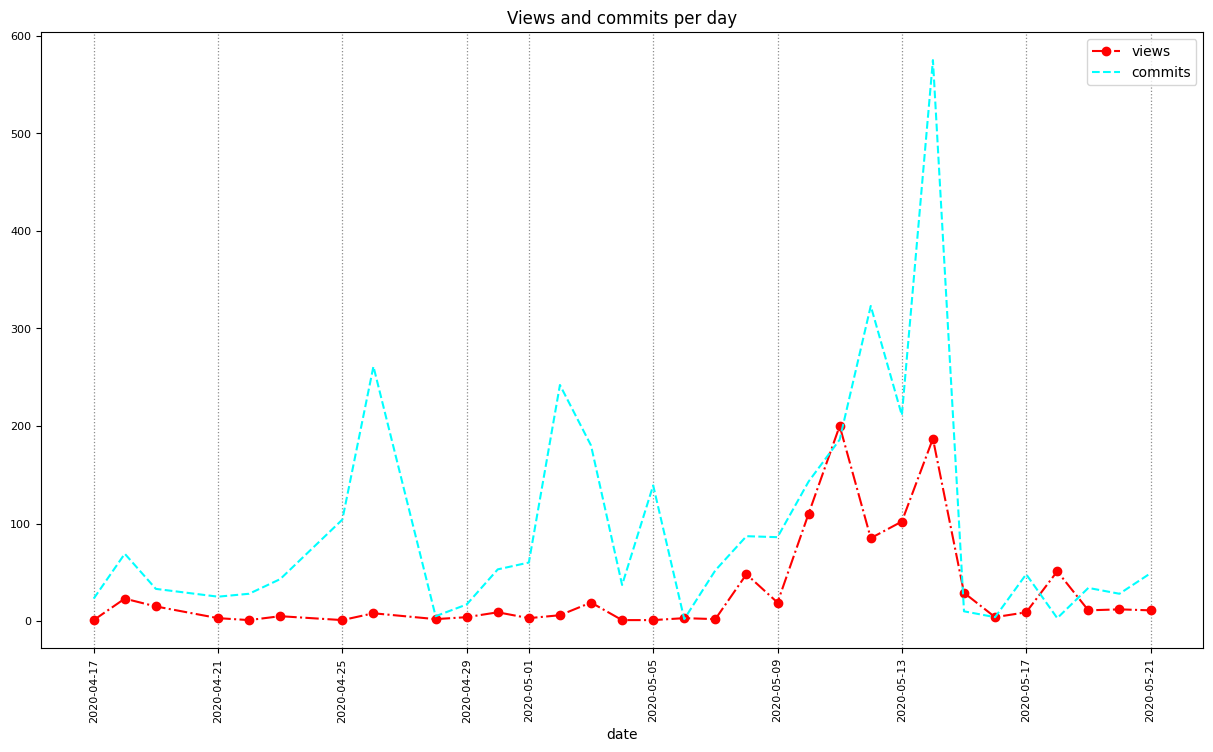

In [5]:
result = pd.merge(df_views, df_commit, left_index=True, right_index=True)
result = result.rename(columns={'count_x': 'views', 'count_y': 'commits'})  

ax = result.plot(
    title='Views and commits per day',
    fontsize=8,
    figsize=(15,8),
    rot= 90,
    color=['red', 'aqua'],
    style=['o-.', '--']
)

ax.grid(axis='x', color='gray', linestyle=':', alpha=0.9, linewidth=0.9)

In [6]:
result.shape

(32, 2)

In [7]:
connect.close()

## Ответ: 2